In [ ]:
!pip install xgboost shap streamlit pyngrok openpyxl -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold,
    cross_val_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap
import joblib

pd.set_option('display.max_columns',None)

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving shrimp dataset.xlsx to shrimp dataset (3).xlsx


In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,DOC,Temperature (Manuall),pH (Manual),Salinity (Manual),DO (Manual),Ammonia (Manual),length,weight
0,9,28.23,8.01,21,6.54,0.003,NaN,NaN
1,10,26.76,7.91,20,6.66,0.003,NaN,NaN
2,11,27.45,7.99,19,6.45,0.003,NaN,NaN
3,12,26.64,8.03,20,6.67,0.004,NaN,NaN
4,13,28.24,8.03,20,6.78,0.003,NaN,NaN


In [ ]:
print(df.info())

print("\nMissing Values\n")

print(df.isnull().sum())

print("\nStatistics\n")

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DOC                     29 non-null     int64  
 1    Temperature (Manuall)  29 non-null     float64
 2   pH (Manual)             29 non-null     float64
 3   Salinity (Manual)       29 non-null     int64  
 4   DO (Manual)             29 non-null     float64
 5   Ammonia (Manual)        29 non-null     float64
 6   length                  24 non-null     float64
 7   weight                  24 non-null     float64
dtypes: float64(6), int64(2)
memory usage: 1.9 KB
None

Missing Values

DOC                       0
 Temperature (Manuall)    0
pH (Manual)               0
Salinity (Manual)         0
DO (Manual)               0
Ammonia (Manual)          0
length                    5
weight                    5
dtype: int64

Statistics

             DOC   Temperature (Manuall)  pH (

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['DOC', 'Temperature (Manuall)', 'pH (Manual)', 'Salinity (Manual)',
       'DO (Manual)', 'Ammonia (Manual)', 'length', 'weight'],
      dtype='object')


In [ ]:
df = df.dropna(subset=['weight','length'])

print("Remaining Rows:", len(df))

Remaining Rows: 24


In [ ]:
df.head()

,DOC,Temperature (Manuall),pH (Manual),Salinity (Manual),DO (Manual),Ammonia (Manual),length,weight
5,14,27.32,8.00,21,7.10,0.003,2.199,2.417
6,15,28.38,8.09,19,6.90,0.003,2.199,2.417
7,16,26.76,7.95,18,6.80,0.003,2.199,2.417
8,17,26.34,7.93,19,6.78,0.003,2.199,2.417
9,18,23.99,7.92,20,6.66,0.003,2.199,2.417


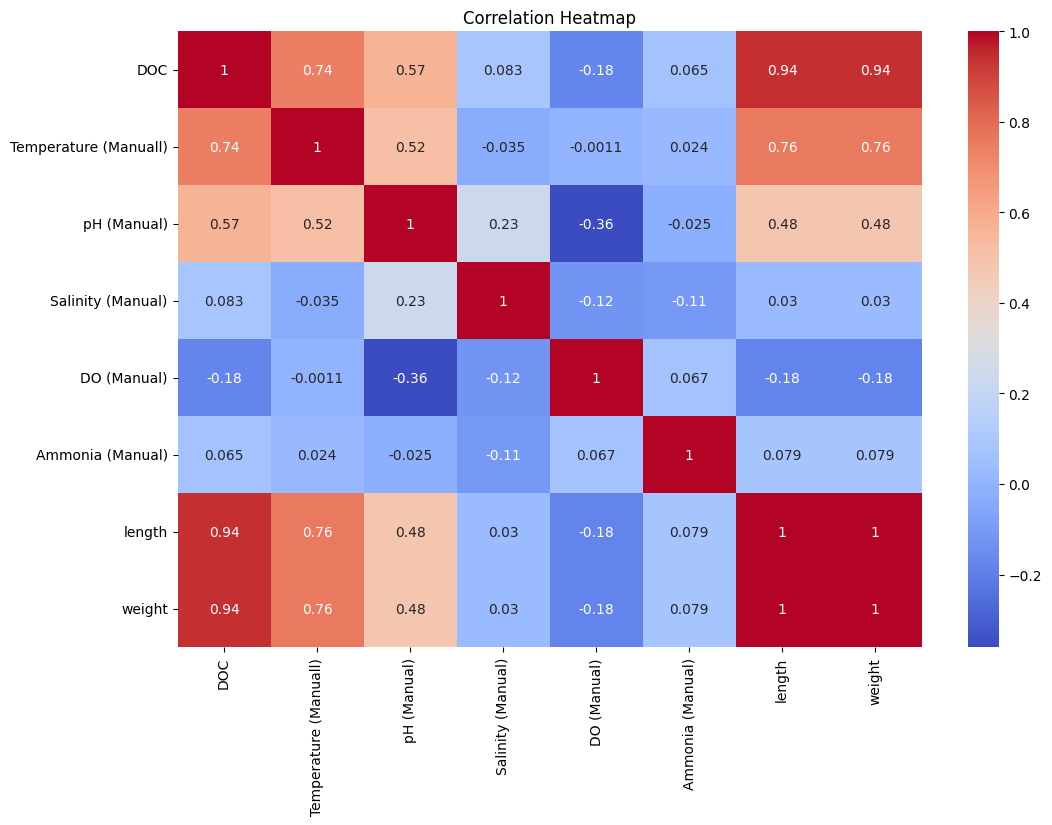

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

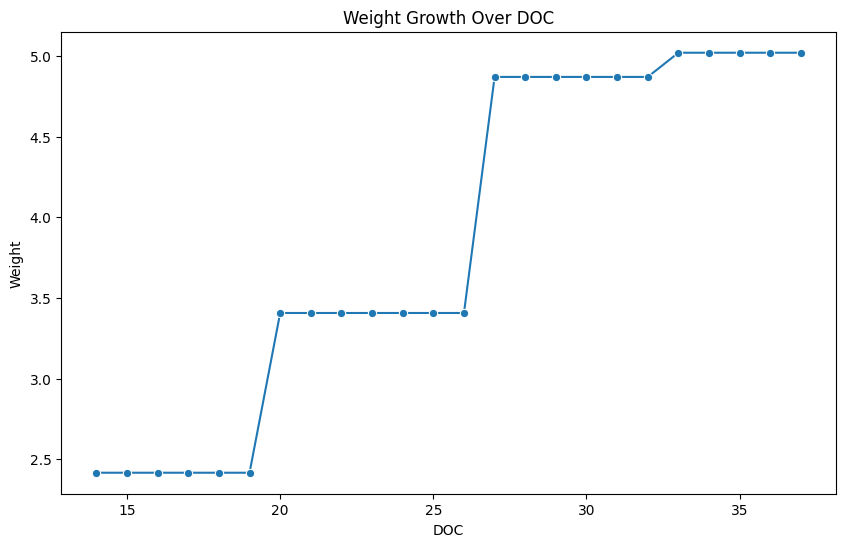

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=df['DOC'],
    y=df['weight'],
    marker='o'
)

plt.title("Weight Growth Over DOC")

plt.xlabel("DOC")

plt.ylabel("Weight")

plt.show()

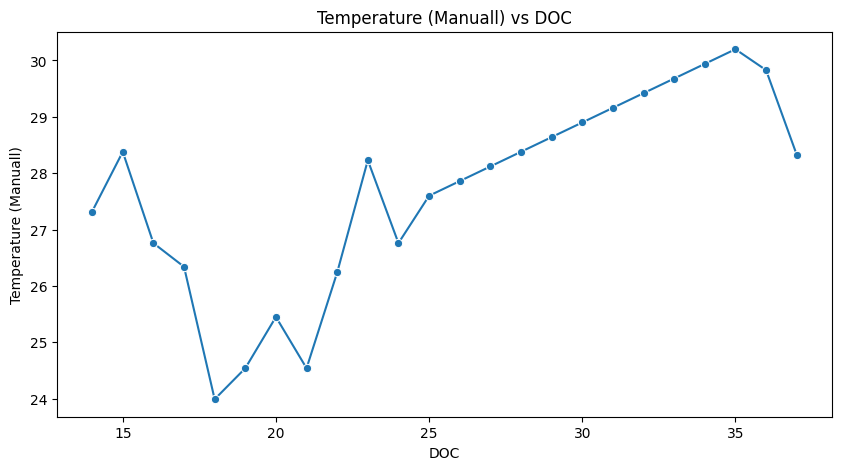

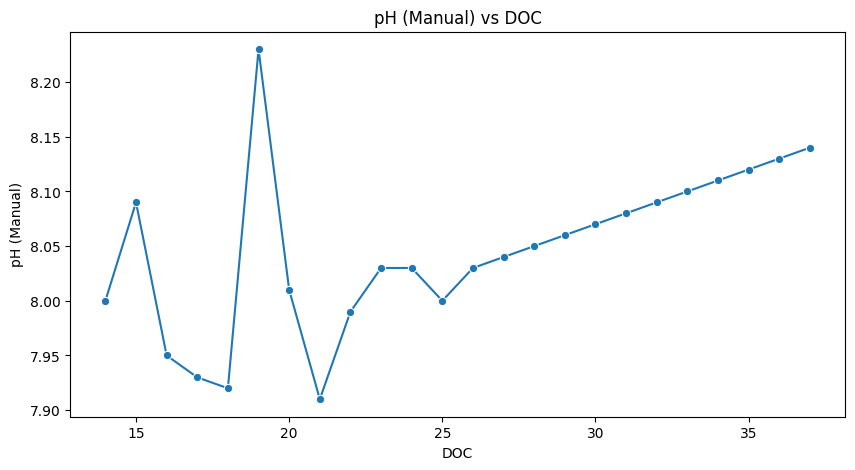

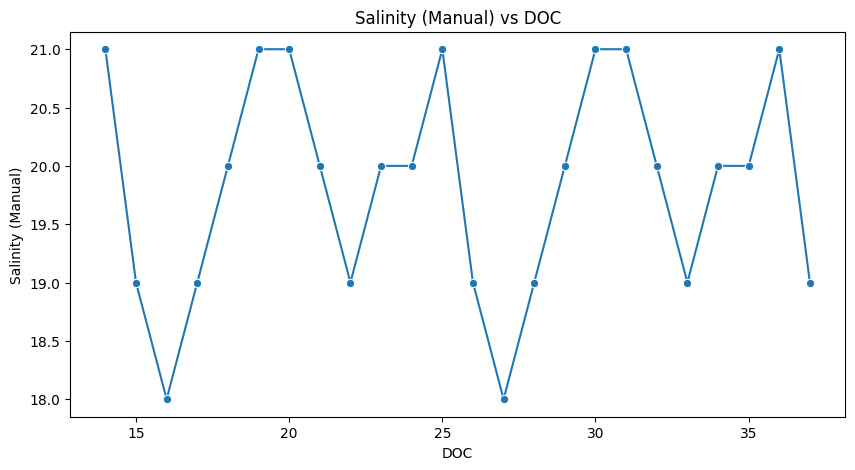

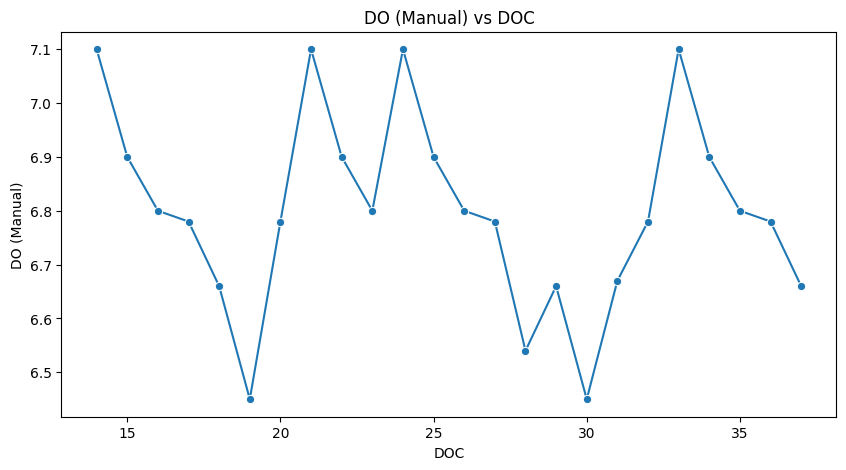

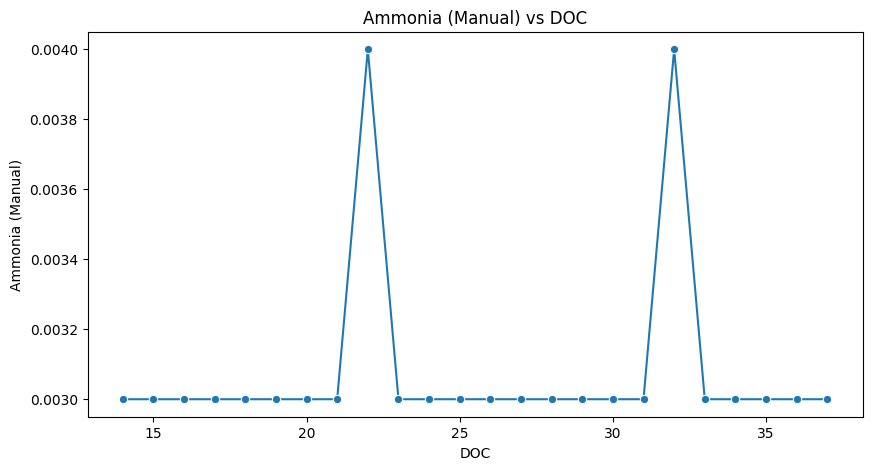

In [ ]:
water_parameters = [
    col for col in df.columns
    if col not in ['DOC', 'weight', 'length']
]

for col in water_parameters:

    plt.figure(figsize=(10,5))

    sns.lineplot(
        x=df['DOC'],
        y=df[col],
        marker='o'
    )

    plt.title(f"{col} vs DOC")

    plt.xlabel("DOC")

    plt.ylabel(col)

    plt.show()

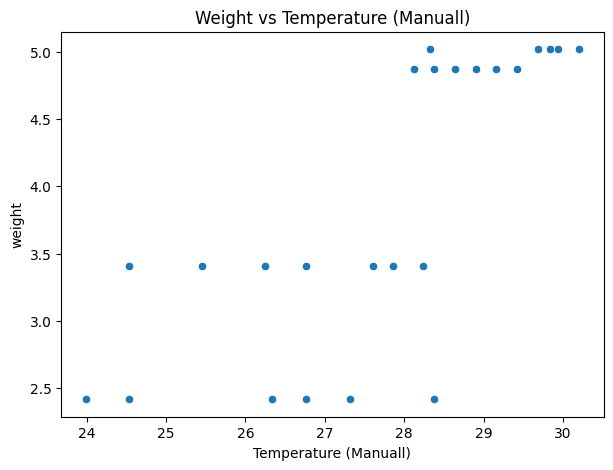

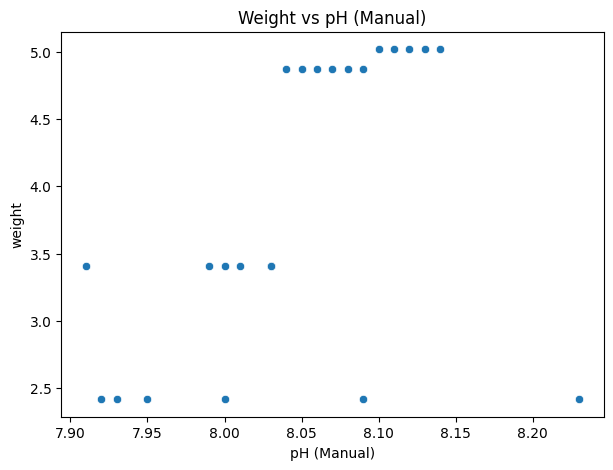

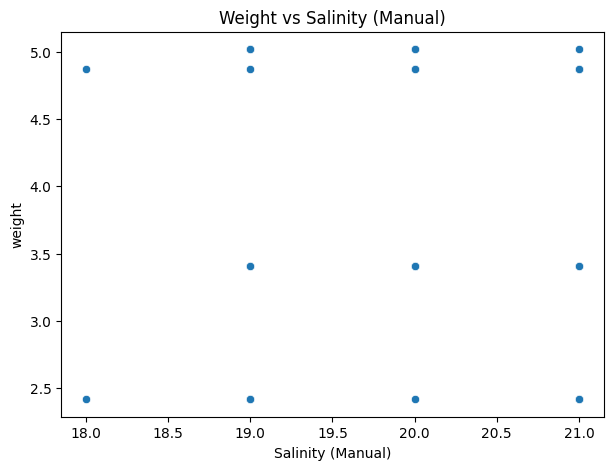

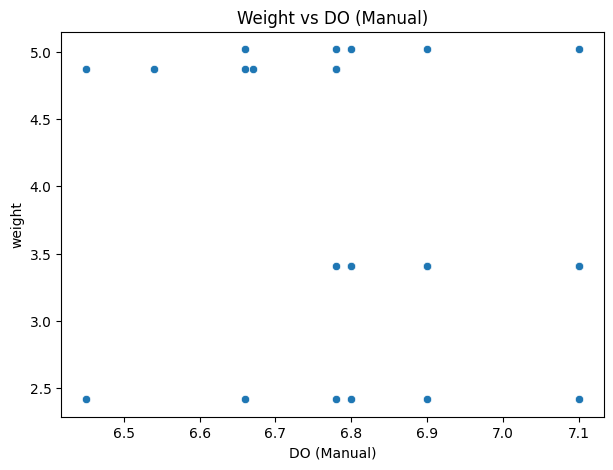

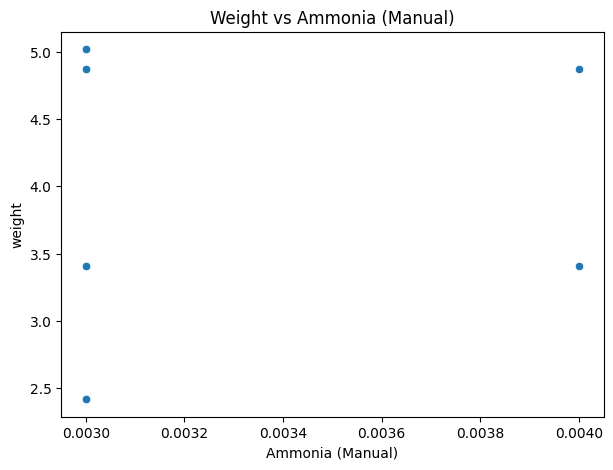

In [ ]:
for col in water_parameters:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        x=df[col],
        y=df['weight']
    )

    plt.title(f"Weight vs {col}")

    plt.show()

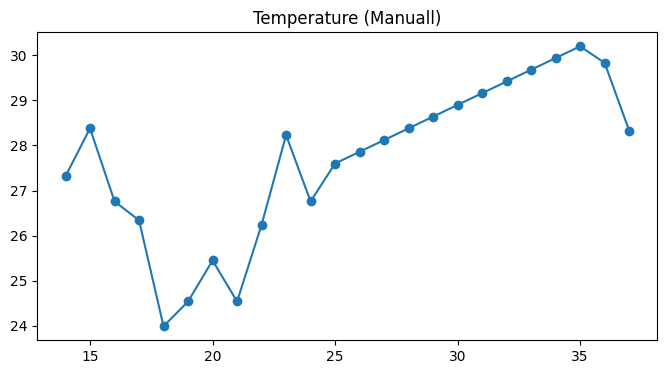

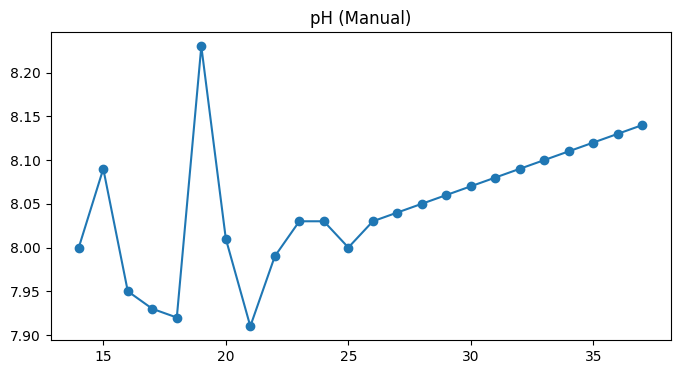

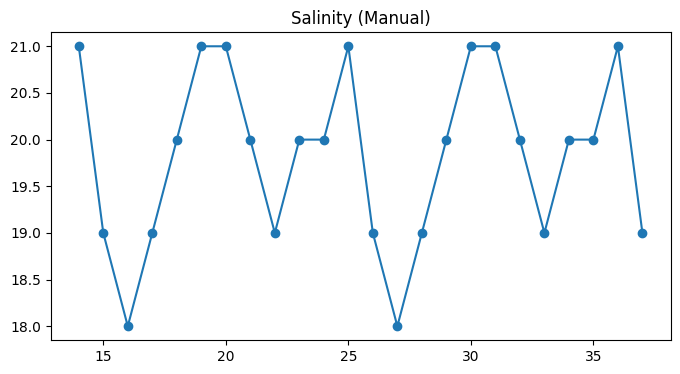

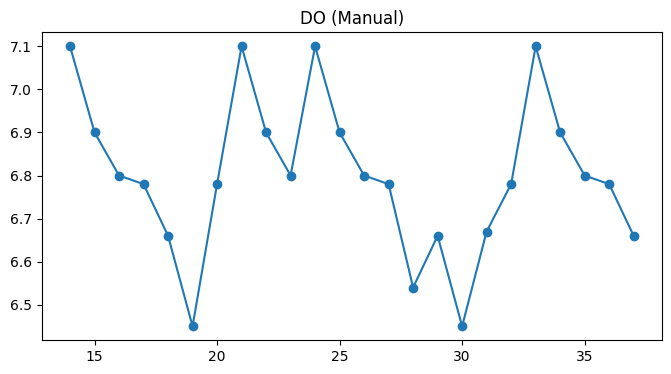

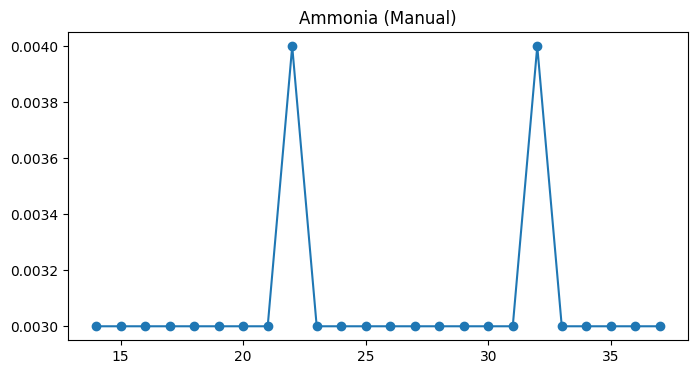

In [ ]:
for col in water_parameters:

    plt.figure(figsize=(8,4))

    plt.plot(
        df['DOC'],
        df[col],
        marker='o'
    )

    plt.title(col)

    plt.show()

In [ ]:
df['Temp_DO'] = (
    df['Temperature (Manuall)'] *
    df['DO (Manual)']
)

df['pH_Ammonia'] = (
    df['pH (Manual)'] *
    df['Ammonia (Manual)']
)

df.head()

,DOC,Temperature (Manuall),pH (Manual),Salinity (Manual),DO (Manual),Ammonia (Manual),length,weight,Temp_DO,pH_Ammonia
5,14,27.32,8.00,21,7.10,0.003,2.199,2.417,193.9720,0.02400
6,15,28.38,8.09,19,6.90,0.003,2.199,2.417,195.8220,0.02427
7,16,26.76,7.95,18,6.80,0.003,2.199,2.417,181.9680,0.02385
8,17,26.34,7.93,19,6.78,0.003,2.199,2.417,178.5852,0.02379
9,18,23.99,7.92,20,6.66,0.003,2.199,2.417,159.7734,0.02376


In [ ]:
X_with_doc = df.drop(columns=['weight', 'length'])

y = df['weight']

print(X_with_doc.columns)

Index(['DOC', 'Temperature (Manuall)', 'pH (Manual)', 'Salinity (Manual)',
       'DO (Manual)', 'Ammonia (Manual)', 'Temp_DO', 'pH_Ammonia'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_with_doc,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.svm import SVR

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ),

    "SVR": SVR(),

    "XGBoost": XGBRegressor(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        objective='reg:squarederror'
    )
}

In [ ]:
results = []

best_model = None
best_r2 = -999

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

    print(f"\n{name}")

    print("MAE :", mae)

    print("RMSE:", rmse)

    print("R2  :", r2)

    if r2 > best_r2:

        best_r2 = r2

        best_model = model

        best_model_name = name


Linear Regression
MAE : 0.14167403059515565
RMSE: 0.17929890609202806
R2  : 0.9643687225658419

Random Forest
MAE : 0.06197466666666847
RMSE: 0.07546040294971179
R2  : 0.9936887649815025

SVR
MAE : 0.7821603882129013
RMSE: 0.8961823318664489
R2  : 0.10983837455458145

XGBoost
MAE : 0.08765109710693367
RMSE: 0.09812209037508514
R2  : 0.9893288875507696


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.141674,0.179299,0.964369
1,Random Forest,0.061975,0.075460,0.993689
2,SVR,0.782160,0.896182,0.109838
3,XGBoost,0.087651,0.098122,0.989329


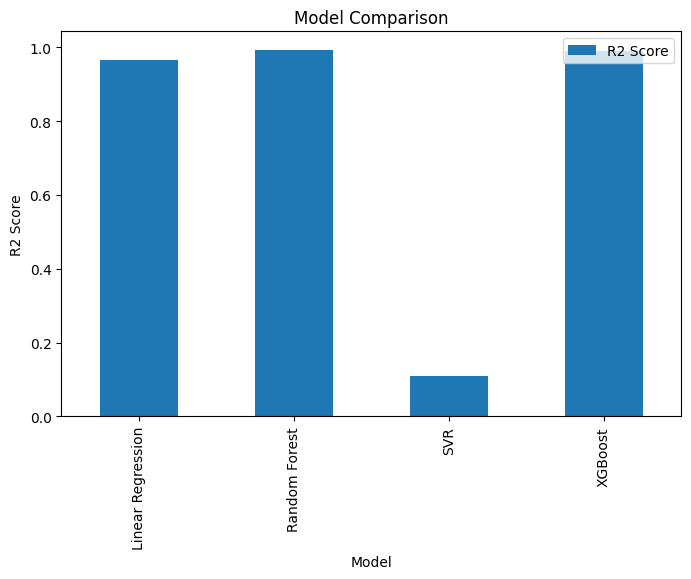

In [ ]:
results_df.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

In [ ]:
print("Best Model:", best_model_name)

print("Best R2:", best_r2)

Best Model: Random Forest
Best R2: 0.9936887649815025


                 Feature  Importance
0                    DOC    0.848843
1  Temperature (Manuall)    0.089838
2            pH (Manual)    0.028309
7             pH_Ammonia    0.015972
6                Temp_DO    0.010120
4            DO (Manual)    0.005210
3      Salinity (Manual)    0.001707
5       Ammonia (Manual)    0.000000


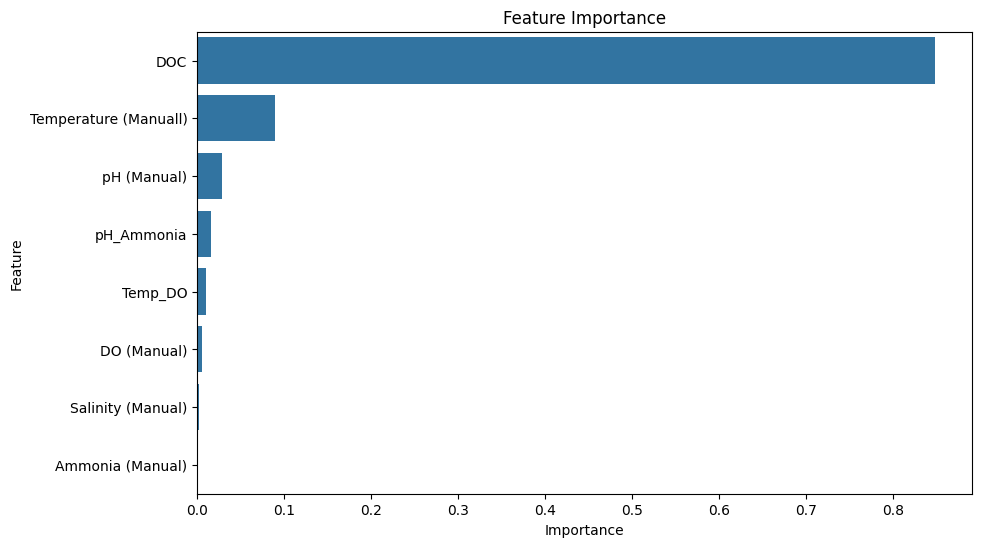

In [ ]:
if hasattr(best_model, 'feature_importances_'):

    importance = pd.DataFrame({

        'Feature': X_with_doc.columns,

        'Importance': best_model.feature_importances_
    })

    importance = importance.sort_values(
        by='Importance',
        ascending=False
    )

    print(importance)

    plt.figure(figsize=(10,6))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance
    )

    plt.title("Feature Importance")

    plt.show()

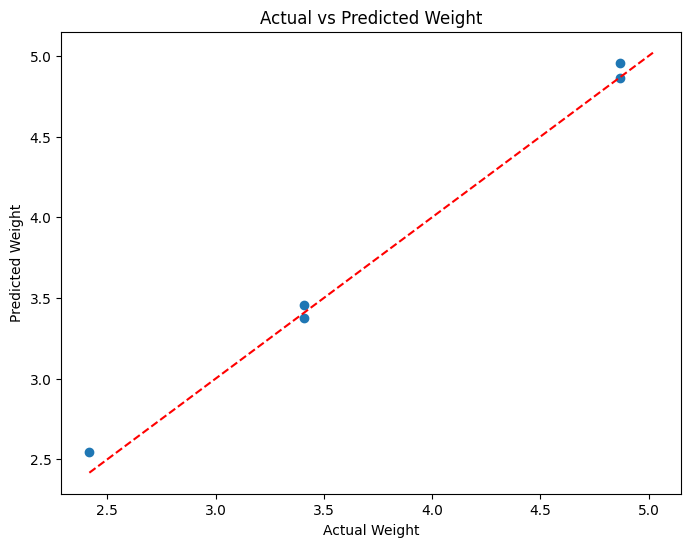

In [ ]:
predictions = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Weight")

plt.ylabel("Predicted Weight")

plt.title("Actual vs Predicted Weight")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.show()

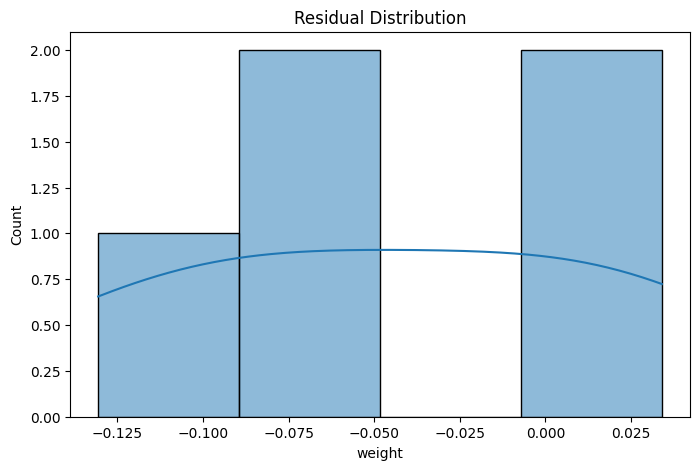

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [ ]:
X_without_doc = df.drop(
    columns=['DOC', 'length', 'weight']
)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_without_doc,
    y,
    test_size=0.2,
    random_state=42
)

rf2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf2.fit(X_train2, y_train2)

pred2 = rf2.predict(X_test2)

r2_without_doc = r2_score(y_test2, pred2)

print("R2 Without DOC:", r2_without_doc)

R2 Without DOC: 0.7805179242907027


In [ ]:
comparison = pd.DataFrame({

    'Experiment': [
        'With DOC',
        'Without DOC'
    ],

    'R2 Score': [
        best_r2,
        r2_without_doc
    ]
})

comparison

,Experiment,R2 Score
0,With DOC,0.993689
1,Without DOC,0.780518


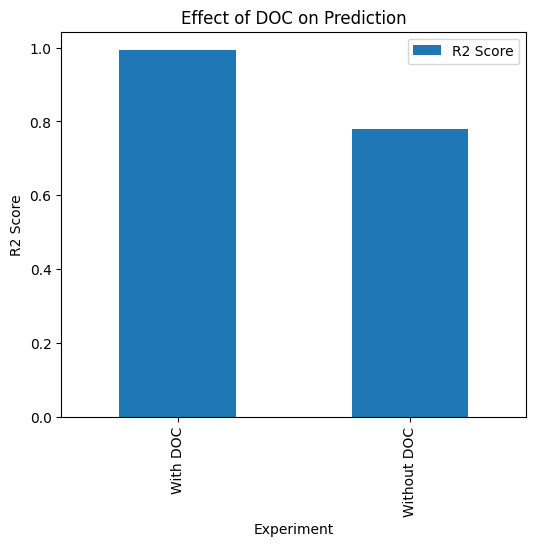

In [ ]:
comparison.plot(
    x='Experiment',
    y='R2 Score',
    kind='bar',
    figsize=(6,5)
)

plt.title("Effect of DOC on Prediction")

plt.ylabel("R2 Score")

plt.show()

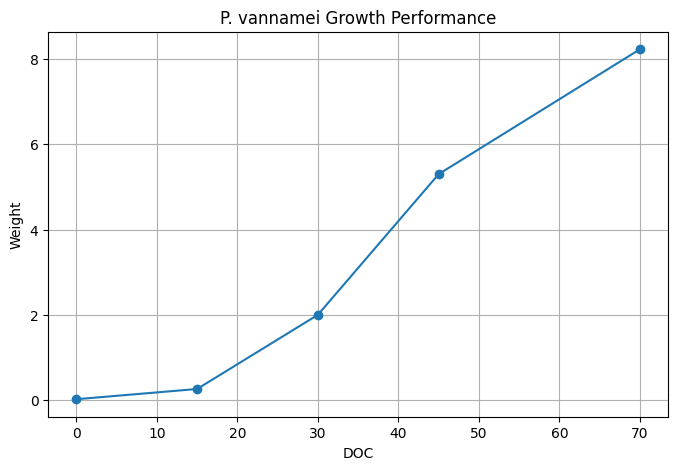

In [ ]:
days = [0,15,30,45,70]

weights = [
    0.02,
    0.26,
    2.00,
    5.30,
    8.23
]

plt.figure(figsize=(8,5))

plt.plot(
    days,
    weights,
    marker='o'
)

plt.xlabel("DOC")

plt.ylabel("Weight")

plt.title(
    "P. vannamei Growth Performance"
)

plt.grid()

plt.show()

In [ ]:
joblib.dump(best_model, 'growth_model.pkl')

print("Model Saved")

Model Saved


In [ ]:
files.download('growth_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>